# Big O: $O(\log n)$ — logarithmic time

Each step **throws away half** of the remaining work. Doubling the input
adds only **one** extra step. That is $\log_2 n$.

The textbook algorithm is **binary search** on a *sorted* list: look at
the middle, then search left or right. After $k$ comparisons the window
has size about $n/2^k$. You are done when the window is $1$, so
$k \approx \log_2 n$.

This notebook does not import `logarithm.py` or the constant sibling.

## Quantum contrast

| problem | classical | quantum |
|---------|-----------|---------|
| sorted search | $O(\log n)$ (this notebook) | not the Grover setting |
| unstructured search | $O(n)$ | Grover $O(\sqrt{n})$ |
| constant vs balanced | $O(2^n)$ worst case | Deutsch–Jozsa $O(1)$ queries |

Binary search needs **structure** (sorted keys). Grover does not.

In [1]:
import math
import matplotlib.pyplot as plt

NS = [1, *range(100, 2001, 100)]  # 1, 100, 200, … 2000

## Binary search, counting comparisons

We count **how many times we look at the midpoint**. That is the
elementary step. Wall-clock time would lie to you on a tiny $n$.

In [2]:
def binary_search(sorted_items: list[int], target: int) -> tuple[int | None, int]:
    lo, hi = 0, len(sorted_items) - 1
    comparisons = 0
    while lo <= hi:
        mid = (lo + hi) // 2
        comparisons += 1
        if sorted_items[mid] == target:
            return mid, comparisons
        if sorted_items[mid] < target:
            lo = mid + 1
        else:
            hi = mid - 1
    return None, comparisons


demo = list(range(16))
idx, steps = binary_search(demo, 11)
print("haystack", demo)
print("find 11 →", idx, "after", steps, "comparisons")
print("ceil(log2(16)) =", math.ceil(math.log2(16)))

haystack [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
find 11 → 11 after 2 comparisons
ceil(log2(16)) = 4


## Worst case vs the closed form

Searching for a value **smaller than every element** never hits, so the
loop runs until the window is empty. That measured count sits on top of
$\lceil\log_2 n\rceil$ (off by at most one, depending on the midpoint
convention).

The $O(1)$ column is the previous tile: one array read, any $n$.

In [3]:
def log2_steps(n: int) -> int:
    return 1 if n <= 1 else math.ceil(math.log2(n))


print(f"{'n':>8}  {'O(1)':>8}  {'measured':>10}  {'ceil(log2 n)':>14}")
ones, measured, theory = [], [], []
for n in NS:
    _, cmp_count = binary_search(list(range(n)), -1)
    ones.append(1)
    measured.append(cmp_count)
    theory.append(log2_steps(n))
    print(f"{n:8d}  {1:8d}  {cmp_count:10d}  {log2_steps(n):14d}")

       n      O(1)    measured    ceil(log2 n)
       1         1           1               1
     100         1           6               7
     200         1           7               8
     300         1           8               9
     400         1           8               9
     500         1           8               9
     600         1           9              10
     700         1           9              10
     800         1           9              10
     900         1           9              10
    1000         1           9              10
    1100         1          10              11
    1200         1          10              11
    1300         1          10              11
    1400         1          10              11
    1500         1          10              11
    1600         1          10              11
    1700         1          10              11
    1800         1          10              11
    1900         1          10              11
    2000     

## Overlay: $O(1)$ vs $O(\log n)$

$n$ runs $1, 100, 200, \ldots, 2000$ on a **linear** axis — the scale a
spreadsheet uses. Blue stays at $1$. Orange (measured) and dotted
(formula) hug a **curve**: steep at the left, almost flat once the list
is already large. That bend *is* $\log n$.

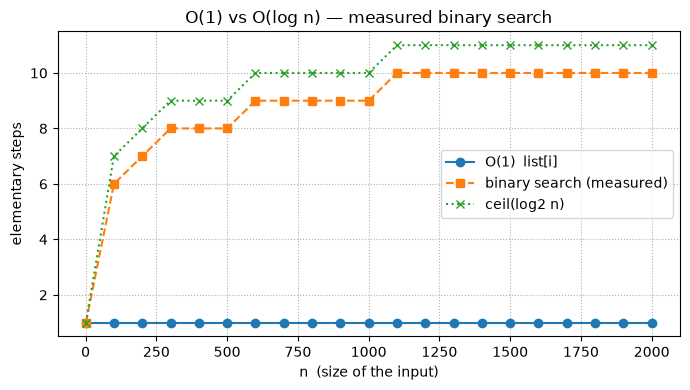

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(NS, ones, "o-", label="O(1)  list[i]")
ax.plot(NS, measured, "s--", label="binary search (measured)")
ax.plot(NS, theory, "x:", label="ceil(log2 n)")
ax.set_xlabel("n  (size of the input)")
ax.set_ylabel("elementary steps")
ax.set_title("O(1) vs O(log n) — measured binary search")
ax.legend()
ax.grid(True, which="both", linestyle=":")
fig.tight_layout()
plt.show()

## Takeaways

- $O(\log n)$ needs a **cut-in-half** structure. Sorted arrays, balanced
  trees, and binary exponentiation all live here.
- If you cannot discard half the candidates, you are not in this class.
  Unsorted search is $O(n)$ (later tile) or Grover $O(\sqrt{n})$.
- On this ordinary $x$-axis, $\log n$ **bends**: extra items get cheaper
  the bigger the list already is.
- Deutsch–Jozsa is *better* than $O(\log n)$ on the query counter: it
  stays $O(1)$ as $n$ (the number of bits) grows.